# Pandas入门

In [1]:
import pandas as pd
import numpy as np

## Series：一维带标签数组  
左边0，1，2...是index(索引)，Pandas自动添加用于追踪行  
支持向量化运算：s*2、s.sum()、s.mean()  
可看作“带索引的NumPy一维数组”

In [2]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])

print(s)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64


## Dataframe：二维表格（核心对象）  
从字典创建

In [3]:
data = {
    'Name' : ['Alice','Bob','Carlie'],
    'Age' :[25,30,35],
    'City' : ['New York','London','Paris']
}
df = pd.DataFrame(data)
print(df)

     Name  Age      City
0   Alice   25  New York
1     Bob   30    London
2  Carlie   35     Paris


快速查看数据

In [6]:
df.head(2) # 前 2 行

,Name,Age,City
0,Alice,25,New York
1,Bob,30,London


In [7]:
df.tail() # 后 5 行（默认）

,Name,Age,City
0,Alice,25,New York
1,Bob,30,London
2,Carlie,35,Paris


In [8]:
df.shape # (3, 3) → (行数, 列数)

(3, 3)

In [9]:
df.info() # 数据类型 + 非空计数

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      int64 
 2   City    3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [10]:
df.describe()     # 数值列的统计摘要

,Age
count,3.0
mean,30.0
std,5.0
min,25.0
25%,27.5
50%,30.0
75%,32.5
max,35.0


In [11]:
df.dtypes # 各列数据类型

Name    object
Age      int64
City    object
dtype: object

### 单列和多列选择的区别

In [12]:
df['Name'] # → Series（单列）

0     Alice
1       Bob
2    Carlie
Name: Name, dtype: object

In [13]:
df[['Name', 'Age']] # → DataFrame（多列，双层括号）

,Name,Age
0,Alice,25
1,Bob,30
2,Carlie,35


## 数据导入 
```python

df = pd.read_csv('data.csv')

df = pd.read_excel('data.xlsx', sheet_name='Sheet1')

df = pd.read_json('data.json')

# 存回去

df.to_csv('clean_data.csv', index=False)

df.to_excel('output.xlsx', index=False)
```
`index=False` 避免导出时把行索引也写成一列 

### 数据选择  

In [24]:
selection ={
    '方法' : ['df[col]','df.loc[ ]','df.iloc[ ]'],
    '用途' : ['按列名选列','按标签选行/列','按位置选行/列'],
    '实例' : ['''df['Age']''','''df.loc[0:2,['Name','Age']]''','''df.iloc[0:3,0:1]''']
}
st = pd.DataFrame(selection)
st.tail()

,方法,用途,实例
0,df[col],按列名选列,df['Age']
1,df.loc[ ],按标签选行/列,"df.loc[0:2,['Name','Age']]"
2,df.iloc[ ],按位置选行/列,"df.iloc[0:3,0:1]"


```python

# loc：标签索引（闭区间）

df.loc[0:2, ['Name', 'Age']]

# iloc：位置索引（左闭右开，类似 Numpy 切片）

df.iloc[0:3, 0:1]
```   
loc用列名和行标签，iloc用数字位置——记住这个区别就不会混  

### 数据筛选  
用布尔表达式筛选行，这是Pandas最高频的操作：


In [26]:

# 单一条件

df[df['Age'] > 30]



,Name,Age,City
2,Carlie,35,Paris


In [27]:
# 多条件组合（用 & |，每个条件加括号）

df[(df['Age'] > 30) & (df['City'] == 'London')]



,Name,Age,City


In [28]:
# isin 筛选枚举值

df[df['City'].isin(['London', 'Paris'])]

,Name,Age,City
1,Bob,30,London
2,Carlie,35,Paris


### 聚合计算  
单列统计  

In [30]:

df['Age'].mean() # 平均值


np.float64(30.0)

In [31]:
df['Age'].sum() # 求和

np.int64(90)

In [32]:
df['Age'].count() # 计数

np.int64(3)

In [33]:
df['City'].value_counts() # 频次统计

City
New York    1
London      1
Paris       1
Name: count, dtype: int64

**groupby分组聚合**

In [34]:
# 单聚合

df.groupby('City')['Age'].mean()


City
London      30.0
New York    25.0
Paris       35.0
Name: Age, dtype: float64

In [36]:
# 多聚合（推荐写法）

summary = df.groupby('City').agg(

avg_age=('Age', 'mean'),

count=('Name', 'count')

)
print(summary)

          avg_age  count
City                    
London       30.0      1
New York     25.0      1
Paris        35.0      1


`groupby` 对应 SQL 的 `GROUP BY`，是数据分析师最核心的技能 。  


### 数据清洗  
缺失值处理  

In [ ]:
# 有趣的动物园动物体检数据
data = {
    "动物": ["🐼 熊猫", "🦊 狐狸", "🐧 企鹅", "🦒 长颈鹿", "🐘 大象", "🦁 狮子", "🐨 考拉", "🦜 鹦鹉"],
    "年龄(岁)": [5, np.nan, 3, 7, 12, 8, np.nan, 2],
    "体重(kg)": [120, 8.5, 25, np.nan, 5000, 190, 10, 1.2],
    "身高(m)": [1.5, 0.4, 0.8, 5.5, 3.2, 1.2, 0.7, np.nan],
    "最爱食物": ["竹子", "葡萄", "鱼", "树叶", "西瓜", "肉", "桉树叶", "瓜子"],
    "健康评分": [95, 88, np.nan, 92, 78, 85, 90, np.nan]
}

df = pd.DataFrame(data)

df.head(8)

,动物,年龄(岁),体重(kg),身高(m),最爱食物,健康评分
0,🐼 熊猫,5.0,120.0,1.5,竹子,95.0
1,🦊 狐狸,NaN,8.5,0.4,葡萄,88.0
2,🐧 企鹅,3.0,25.0,0.8,鱼,NaN
3,🦒 长颈鹿,7.0,NaN,5.5,树叶,92.0
4,🐘 大象,12.0,5000.0,3.2,西瓜,78.0
5,🦁 狮子,8.0,190.0,1.2,肉,85.0
6,🐨 考拉,NaN,10.0,0.7,桉树叶,90.0
7,🦜 鹦鹉,2.0,1.2,NaN,瓜子,NaN


In [41]:
df.isnull().sum() # 每列缺失值数量

动物        0
年龄(岁)     2
体重(kg)    1
身高(m)     1
最爱食物      0
健康评分      2
dtype: int64

In [42]:
df.dropna() # 删除含缺失值的行

,动物,年龄(岁),体重(kg),身高(m),最爱食物,健康评分
0,🐼 熊猫,5.0,120.0,1.5,竹子,95.0
4,🐘 大象,12.0,5000.0,3.2,西瓜,78.0
5,🦁 狮子,8.0,190.0,1.2,肉,85.0


In [ ]:
df.dropna(subset=['年龄(岁)']) # 只在 年龄(岁) 列有缺失时删除

,动物,年龄(岁),体重(kg),身高(m),最爱食物,健康评分
0,🐼 熊猫,5.0,120.0,1.5,竹子,95.0
2,🐧 企鹅,3.0,25.0,0.8,鱼,NaN
3,🦒 长颈鹿,7.0,NaN,5.5,树叶,92.0
4,🐘 大象,12.0,5000.0,3.2,西瓜,78.0
5,🦁 狮子,8.0,190.0,1.2,肉,85.0
7,🦜 鹦鹉,2.0,1.2,NaN,瓜子,NaN


In [49]:
df['年龄(岁)'].fillna(df['年龄(岁)'].mean()) # 用均值填充

0     5.000000
1     6.166667
2     3.000000
3     7.000000
4    12.000000
5     8.000000
6     6.166667
7     2.000000
Name: 年龄(岁), dtype: float64

In [50]:
df['年龄(岁)'].fillna(0) # 用常数填充

0     5.0
1     0.0
2     3.0
3     7.0
4    12.0
5     8.0
6     0.0
7     2.0
Name: 年龄(岁), dtype: float64

In [ ]:
df['年龄(岁)'].ffill() #forward fill，向前填充，用前面一个有效值填充缺失值

0     5.0
1     5.0
2     3.0
3     7.0
4    12.0
5     8.0
6     8.0
7     2.0
Name: 年龄(岁), dtype: float64

In [53]:
df['年龄(岁)'].bfill() #backward fill，用后面一个有效值填充缺失值

0     5.0
1     3.0
2     3.0
3     7.0
4    12.0
5     8.0
6     2.0
7     2.0
Name: 年龄(岁), dtype: float64

⚠️ 不要盲目 `dropna()`——先理解缺失原因再决定策略 


#### 重复值处理  

In [63]:
data = {
    "动物": ["🐼 熊猫", "🦊 狐狸", "🐧 企鹅", "🦒 长颈鹿", "🐘 大象", "🦁 狮子", "🐼 熊猫", "🦜 鹦鹉"],
    "年龄(岁)": [5, np.nan, 3, 7, 12, 8, 5, "2"],  
    "体重(kg)": [120, 8.5, 25, np.nan, 5000, 190, 120, 1.2],
    "身高(m)": [1.5, 0.4, 0.8, 5.5, 3.2, 1.2, 1.5, np.nan],
    "健康评分": [95, 88, np.nan, 92, 78, 85, 95, np.nan]
}
df = pd.DataFrame(data)

In [ ]:
df.duplicated() #标记重复行

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
dtype: bool

In [ ]:
df[df.duplicated(keep=False)] #显示所有重复行

,动物,年龄(岁),体重(kg),身高(m),健康评分
0,🐼 熊猫,5,120.0,1.5,95.0
6,🐼 熊猫,5,120.0,1.5,95.0


In [ ]:
df.drop_duplicates() #删除完全重复的行

,动物,年龄(岁),体重(kg),身高(m),健康评分
0,🐼 熊猫,5,120.0,1.5,95.0
1,🦊 狐狸,NaN,8.5,0.4,88.0
2,🐧 企鹅,3,25.0,0.8,NaN
3,🦒 长颈鹿,7,NaN,5.5,92.0
4,🐘 大象,12,5000.0,3.2,78.0
5,🦁 狮子,8,190.0,1.2,85.0
7,🦜 鹦鹉,2,1.2,NaN,NaN


In [69]:
df.drop_duplicates(subset=['动物']) #按特定列判重

,动物,年龄(岁),体重(kg),身高(m),健康评分
0,🐼 熊猫,5,120.0,1.5,95.0
1,🦊 狐狸,NaN,8.5,0.4,88.0
2,🐧 企鹅,3,25.0,0.8,NaN
3,🦒 长颈鹿,7,NaN,5.5,92.0
4,🐘 大象,12,5000.0,3.2,78.0
5,🦁 狮子,8,190.0,1.2,85.0
7,🦜 鹦鹉,2,1.2,NaN,NaN


类型转换

In [70]:
df.dtypes

动物         object
年龄(岁)      object
体重(kg)    float64
身高(m)     float64
健康评分      float64
dtype: object

把年龄转成数值类型

In [72]:
df['年龄(岁)'] = pd.to_numeric(df['年龄(岁)'], errors='coerce')
print("转换后类型：", df['年龄(岁)'].dtype)
print(df['年龄(岁)'])

转换后类型： float64
0     5.0
1     NaN
2     3.0
3     7.0
4    12.0
5     8.0
6     5.0
7     2.0
Name: 年龄(岁), dtype: float64


errors='coerce'的意思是：如果转不了数字，就变成 NaN（不会报错）

In [74]:
# 把健康评分从float转成int(先处理NaN)
# 先把NaN填上，再转int
df_temp = df.copy()
df_temp['健康评分'] = df_temp['健康评分'].fillna(0).astype(int)
print("转int后的健康评分:\n", df_temp['健康评分'])

转int后的健康评分:
 0    95
1    88
2     0
3    92
4    78
5    85
6    95
7     0
Name: 健康评分, dtype: int64


In [75]:
# 把动物列转成category类型（节省内存）
df['动物'] = df['动物'].astype('category')
print("动物列的类型：", df['动物'].dtype)
print("动物类别：", df['动物'].cat.categories)

动物列的类型： category
动物类别： Index(['🐘 大象', '🐧 企鹅', '🐼 熊猫', '🦁 狮子', '🦊 狐狸', '🦒 长颈鹿', '🦜 鹦鹉'], dtype='object')


In [ ]:
import matplotlib.pyplot as plt 

#设置字体为黑体（Windows常用）或微软雅黑，以便支持中文显示

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']

#解决保存图像时负号'-'显示为方块的问题

plt.rcParams['axes.unicode_minus'] = False

#适配表情包
plt.rcParams["font.family"] = ["Segoe UI Emoji", "SimHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

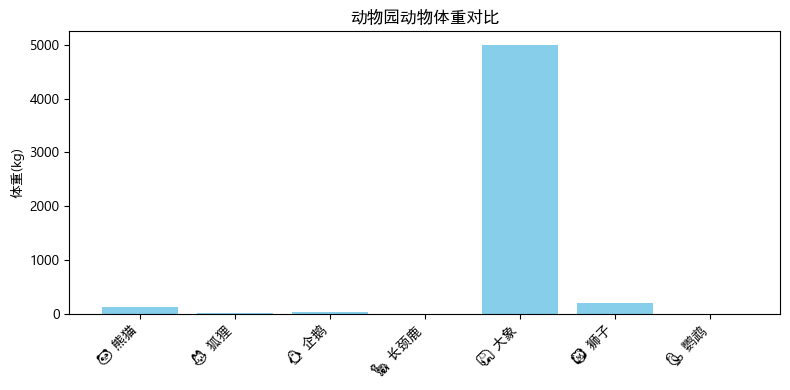

In [80]:
plt.figure(figsize=(8, 4))
plt.bar(df["动物"], df["体重(kg)"], color="skyblue")
plt.ylabel("体重(kg)")
plt.title("动物园动物体重对比")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

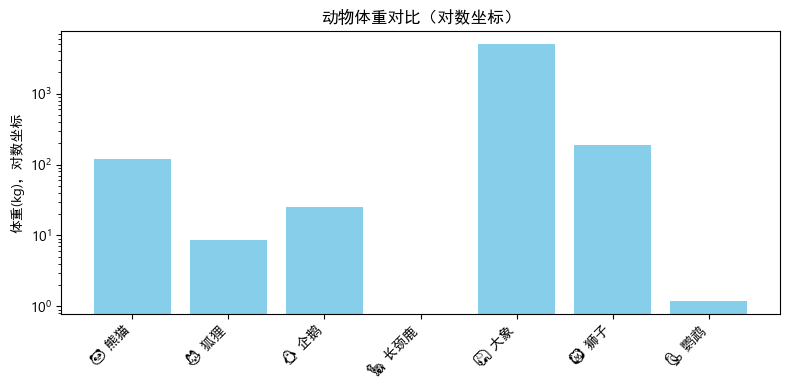

In [81]:
plt.figure(figsize=(8, 4))
plt.bar(df["动物"], df["体重(kg)"], color="skyblue")
plt.yscale("log")
plt.ylabel("体重(kg)，对数坐标")
plt.title("动物体重对比（对数坐标）")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()